### 实验01：噪声特性分析（含参考地差分分析）

#### 实验内容
1. 静态噪声测量（零负载状态）
2. 噪声统计分析（均值、标准差、峰峰值）
3. 噪声频谱分析（FFT）
4. 有效位数（ENOB）计算
5. **参考地相关性分析**
6. **差分噪声分析**（探究差分是否可降低噪声）

#### 输入数据说明
- 文件格式：CSV，三列数据
- 列定义：Time_ms（时间戳，毫秒）, RawValue（传感器ADC值）, RawGround（参考地ADC值）
- 采集条件：传感器零负载状态，采集时长 ≥20s
- 采样频率：200 Hz

#### 1. 导入库与参数配置

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.stats import norm, pearsonr, spearmanr
from scipy import signal
import sys, os

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
from plot_style import apply_measurement_style, COLORS, add_subplot_label, save_figure, SAVE_DIRS

apply_measurement_style()
SAVE_DIR = SAVE_DIRS[1]

FS = 200
DT = 1 / FS
V_REF = 5.0
ADC_BITS = 16
LSB = V_REF / (2**15)

print(f"采样频率: {FS} Hz")
print(f"采样周期: {DT*1000:.1f} ms")
print(f"LSB电压: {LSB*1000:.4f} mV")

采样频率: 200 Hz
采样周期: 5.0 ms
LSB电压: 0.1526 mV


#### 2. 数据加载

In [9]:
def load_sensor_data(file_path):
    df = pd.read_csv(file_path)
    df.columns = ['Time_ms', 'RawValue', 'RawGround']
    df['Time_s'] = df['Time_ms'] / 1000
    df['Voltage_mV'] = df['RawValue'] * LSB * 1000
    df['Ground_mV'] = df['RawGround'] * LSB * 1000
    df['Differential'] = df['RawValue'] - df['RawGround']
    return df

_BASE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "..", "workspace", "test1")
FILE_NOISE = os.path.join(_BASE, "Tactile_AD1_R0_C0_20251219_175435.csv")

df = load_sensor_data(FILE_NOISE)
print(f"数据点数: {len(df)}")
print(f"采样时长: {df['Time_s'].max():.2f} s")

数据点数: 5868
采样时长: 29.34 s


#### 3. 异常值检测与剔除

In [10]:
raw = df['RawValue'].values
ground = df['RawGround'].values
diff = df['Differential'].values

# 基于IQR的异常值检测（对信号通道）
Q1, Q3 = np.percentile(raw, [25, 75])
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outlier_mask = (raw < lower_bound) | (raw > upper_bound)
raw_clean = raw[~outlier_mask]
ground_clean = ground[~outlier_mask]
diff_clean = diff[~outlier_mask]

print(f"异常值数量: {np.sum(outlier_mask)}")
print(f"有效数据点: {len(raw_clean)}")

异常值数量: 2
有效数据点: 5866


#### 4. 信号通道噪声统计分析

In [11]:
# 信号通道统计量
signal_mean = np.mean(raw_clean)
signal_std = np.std(raw_clean)
signal_pp = np.max(raw_clean) - np.min(raw_clean)
signal_6sigma = 6 * signal_std

# 参考地统计量
ground_mean = np.mean(ground_clean)
ground_std = np.std(ground_clean)
ground_pp = np.max(ground_clean) - np.min(ground_clean)

# 差分信号统计量
diff_mean = np.mean(diff_clean)
diff_std = np.std(diff_clean)
diff_pp = np.max(diff_clean) - np.min(diff_clean)
diff_6sigma = 6 * diff_std

print("="*70)
print("【噪声统计结果】")
print("="*70)
print(f"{'通道':<15} {'均值(LSB)':<15} {'标准差σ(LSB)':<15} {'峰峰值(LSB)':<15}")
print("-"*70)
print(f"{'信号(RawValue)':<15} {signal_mean:<15.3f} {signal_std:<15.3f} {signal_pp:<15}")
print(f"{'参考地(Ground)':<15} {ground_mean:<15.3f} {ground_std:<15.3f} {ground_pp:<15}")
print(f"{'差分(Diff)':<15} {diff_mean:<15.3f} {diff_std:<15.3f} {diff_pp:<15}")

【噪声统计结果】
通道              均值(LSB)         标准差σ(LSB)       峰峰值(LSB)       
----------------------------------------------------------------------
信号(RawValue)    -5.825          1.045           7              
参考地(Ground)     3.545           1.167           8              
差分(Diff)        -9.370          1.562           11             


#### 5. 参考地相关性分析

In [12]:
# 去均值处理
signal_ac = raw_clean - signal_mean
ground_ac = ground_clean - ground_mean

# Pearson相关系数（线性相关性）
pearson_corr, pearson_p = pearsonr(signal_ac, ground_ac)

# Spearman相关系数（单调相关性）
spearman_corr, spearman_p = spearmanr(signal_ac, ground_ac)

# 互相关函数（检测时延相关性）
correlation = signal.correlate(signal_ac, ground_ac, mode='full')
lags = signal.correlation_lags(len(signal_ac), len(ground_ac), mode='full')
correlation_normalized = correlation / (np.std(signal_ac) * np.std(ground_ac) * len(signal_ac))
max_corr_idx = np.argmax(np.abs(correlation_normalized))
max_corr_lag = lags[max_corr_idx]
max_corr_value = correlation_normalized[max_corr_idx]

# 协方差
covariance = np.cov(signal_ac, ground_ac)[0, 1]

print("="*70)
print("【参考地与信号相关性分析】")
print("="*70)
print(f"Pearson相关系数:   {pearson_corr:>10.6f} (p = {pearson_p:.2e})")
print(f"Spearman相关系数:  {spearman_corr:>10.6f} (p = {spearman_p:.2e})")
print(f"协方差:            {covariance:>10.4f} LSB²")
print(f"最大互相关:        {max_corr_value:>10.6f} (时延 = {max_corr_lag} 采样点)")
print()
print("相关性解释:")
if abs(pearson_corr) > 0.7:
    print("  → 信号与参考地存在强相关性，差分可有效降低共模噪声")
elif abs(pearson_corr) > 0.3:
    print("  → 信号与参考地存在中等相关性，差分可部分降低共模噪声")
else:
    print("  → 信号与参考地相关性较弱，差分效果有限")

【参考地与信号相关性分析】
Pearson相关系数:     0.007010 (p = 5.91e-01)
Spearman相关系数:    0.009830 (p = 4.52e-01)
协方差:                0.0086 LSB²
最大互相关:          0.043564 (时延 = -109 采样点)

相关性解释:
  → 信号与参考地相关性较弱，差分效果有限


Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test1\png\01_noise_overview.png


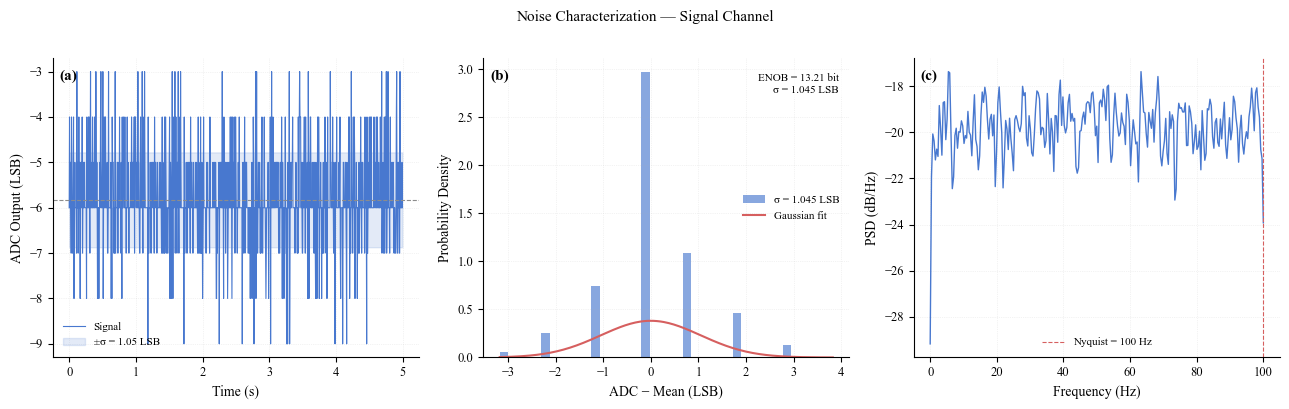

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test1\png\01a_time.png
Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test1\png\01b_hist.png
Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test1\png\01c_psd.png


In [13]:
# ── Fig 1: 3-panel noise overview ────────────────────────────────────────────
# (a) time-domain segment  (b) histogram + Gaussian  (c) Welch PSD dB + Nyquist
ENOB_signal = ADC_BITS - np.log2(signal_std * 6.6)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# (a) Time-domain segment (first 5 s)
ax = axes[0]
n_show = min(int(5 * FS), len(raw_clean))
t = np.arange(n_show) * DT
ax.plot(t, raw_clean[:n_show], color=COLORS["blue"], linewidth=0.8, label="Signal")
ax.axhline(signal_mean, color=COLORS["gray"], linewidth=0.8, linestyle="--")
ax.fill_between(t,
                signal_mean - signal_std, signal_mean + signal_std,
                color=COLORS["blue"], alpha=0.15, label=f"±σ = {signal_std:.2f} LSB")
ax.set_xlabel("Time (s)")
ax.set_ylabel("ADC Output (LSB)")
ax.legend(frameon=False, fontsize=8)
add_subplot_label(ax, "(a)")

# (b) Histogram + Gaussian fit
ax = axes[1]
counts, bins, _ = ax.hist(raw_clean - signal_mean, bins=40, density=True,
                           color=COLORS["blue"], alpha=0.65, edgecolor="none",
                           label=f"σ = {signal_std:.3f} LSB")
x_g = np.linspace(bins[0], bins[-1], 200)
ax.plot(x_g, norm.pdf(x_g, 0, signal_std),
        color=COLORS["red"], linewidth=1.5, label="Gaussian fit")
ax.set_xlabel("ADC − Mean (LSB)")
ax.set_ylabel("Probability Density")
ax.legend(frameon=False, fontsize=8)
ax.text(0.97, 0.95,
        f"ENOB = {ENOB_signal:.2f} bit\nσ = {signal_std:.3f} LSB",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))
add_subplot_label(ax, "(b)")

# (c) Welch PSD in dB + Nyquist line
ax = axes[2]
f_welch, psd = signal.welch(raw_clean - signal_mean, fs=FS, nperseg=512)
psd_dB = 10 * np.log10(psd + 1e-30)
ax.plot(f_welch, psd_dB, color=COLORS["blue"], linewidth=1.0)
ax.axvline(FS / 2, color=COLORS["red"], linewidth=0.8, linestyle="--",
           label=f"Nyquist = {FS//2} Hz")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (dB/Hz)")
ax.legend(frameon=False, fontsize=8)
add_subplot_label(ax, "(c)")

fig.suptitle("Noise Characterization — Signal Channel", fontsize=11, y=1.01)
plt.tight_layout()
p = save_figure(fig, SAVE_DIR, "01_noise_overview")
print(f"Saved: {p}")
plt.show()

# ── Individual sub-figures ────────────────────────────────────────────────────
for panel_idx, (panel_ax, stem) in enumerate(zip(axes, ["01a_time", "01b_hist", "01c_psd"])):
    fig_s, ax_s = plt.subplots(figsize=(5, 4))
    if panel_idx == 0:
        ax_s.plot(t, raw_clean[:n_show], color=COLORS["blue"], linewidth=0.8)
        ax_s.axhline(signal_mean, color=COLORS["gray"], linewidth=0.8, linestyle="--")
        ax_s.fill_between(t, signal_mean - signal_std, signal_mean + signal_std,
                          color=COLORS["blue"], alpha=0.15)
        ax_s.set_xlabel("Time (s)"); ax_s.set_ylabel("ADC Output (LSB)")
    elif panel_idx == 1:
        ax_s.hist(raw_clean - signal_mean, bins=40, density=True,
                  color=COLORS["blue"], alpha=0.65, edgecolor="none")
        ax_s.plot(x_g, norm.pdf(x_g, 0, signal_std), color=COLORS["red"], linewidth=1.5)
        ax_s.set_xlabel("ADC − Mean (LSB)"); ax_s.set_ylabel("Probability Density")
        ax_s.text(0.97, 0.95, f"ENOB = {ENOB_signal:.2f} bit\nσ = {signal_std:.3f} LSB",
                  transform=ax_s.transAxes, ha="right", va="top", fontsize=8,
                  bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))
    else:
        ax_s.plot(f_welch, psd_dB, color=COLORS["blue"], linewidth=1.0)
        ax_s.axvline(FS / 2, color=COLORS["red"], linewidth=0.8, linestyle="--")
        ax_s.set_xlabel("Frequency (Hz)"); ax_s.set_ylabel("PSD (dB/Hz)")
    plt.tight_layout()
    p = save_figure(fig_s, SAVE_DIR, stem)
    print(f"Saved: {p}")
    plt.close(fig_s)

#### 6. 差分降噪效果分析

In [14]:
# 差分降噪效果计算
noise_reduction_ratio = signal_std / diff_std if diff_std > 0 else np.inf
noise_reduction_percent = (1 - diff_std / signal_std) * 100
noise_reduction_dB = 20 * np.log10(signal_std / diff_std) if diff_std > 0 else np.inf

# 理论最优差分效果（假设完全相关的共模噪声）
# 差分后方差 = Var(S) + Var(G) - 2*Cov(S,G)
theoretical_diff_var = signal_std**2 + ground_std**2 - 2 * covariance
theoretical_diff_std = np.sqrt(max(0, theoretical_diff_var))

print("="*70)
print("【差分降噪效果分析】")
print("="*70)
print(f"原始信号噪声 σ:        {signal_std:.4f} LSB")
print(f"参考地噪声 σ:          {ground_std:.4f} LSB")
print(f"差分信号噪声 σ:        {diff_std:.4f} LSB")
print(f"理论差分噪声 σ:        {theoretical_diff_std:.4f} LSB")
print()
print(f"降噪比:                {noise_reduction_ratio:.3f}x")
print(f"噪声降低:              {noise_reduction_percent:.2f}%")
print(f"噪声抑制:              {noise_reduction_dB:.2f} dB")
print()

if noise_reduction_percent > 0:
    print("★ 结论: 差分能够有效降低噪声！")
    if noise_reduction_percent > 30:
        print("   → 强烈建议使用差分信号进行后续分析")
    elif noise_reduction_percent > 10:
        print("   → 建议使用差分信号")
    else:
        print("   → 差分效果有限，可根据具体需求选择")
else:
    print("★ 结论: 差分反而增加了噪声")
    print("   → 信号和参考地噪声不相关或负相关，不建议使用差分")

【差分降噪效果分析】
原始信号噪声 σ:        1.0452 LSB
参考地噪声 σ:          1.1674 LSB
差分信号噪声 σ:        1.5615 LSB
理论差分噪声 σ:        1.5615 LSB

降噪比:                0.669x
噪声降低:              -49.39%
噪声抑制:              -3.49 dB

★ 结论: 差分反而增加了噪声
   → 信号和参考地噪声不相关或负相关，不建议使用差分


#### 7. 频谱分析对比

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test1\png\01_spectrum_comparison.png


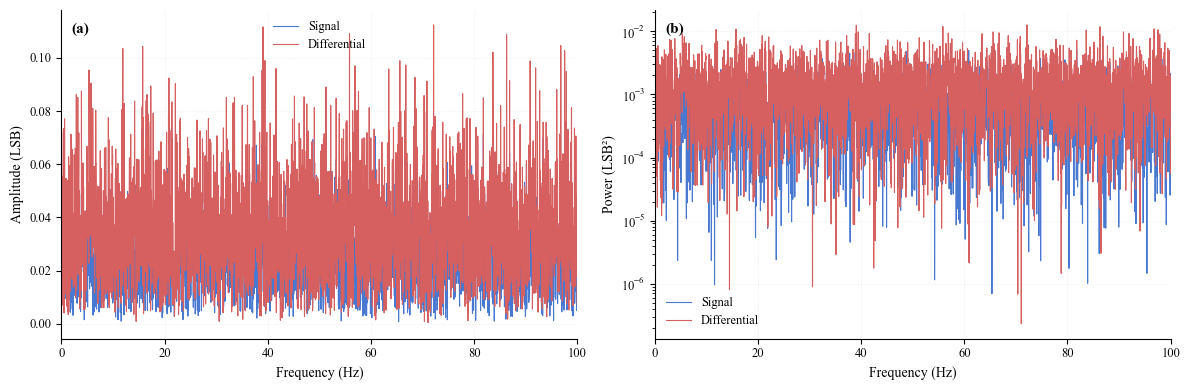

In [15]:
# Spectrum comparison (signal vs differential) — kept for reference
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

def compute_spectrum(data, fs):
    N = len(data)
    yf = fft(data - np.mean(data))
    xf = fftfreq(N, 1/fs)[:N//2]
    amplitude = 2.0/N * np.abs(yf[0:N//2])
    return xf, amplitude

freq_signal, amp_signal = compute_spectrum(raw_clean, FS)
freq_diff,   amp_diff   = compute_spectrum(diff_clean, FS)

ax = axes[0]
ax.plot(freq_signal, amp_signal, color=COLORS["blue"], linewidth=0.8, label="Signal")
ax.plot(freq_diff,   amp_diff,   color=COLORS["red"],  linewidth=0.8, label="Differential")
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Amplitude (LSB)")
ax.set_xlim([0, FS/2]); ax.legend(frameon=False)
add_subplot_label(ax, "(a)")

ax = axes[1]
ax.semilogy(freq_signal[1:], amp_signal[1:]**2, color=COLORS["blue"], linewidth=0.8, label="Signal")
ax.semilogy(freq_diff[1:],   amp_diff[1:]**2,   color=COLORS["red"],  linewidth=0.8, label="Differential")
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Power (LSB²)")
ax.set_xlim([0, FS/2]); ax.legend(frameon=False)
add_subplot_label(ax, "(b)")

plt.tight_layout()
p = save_figure(fig, SAVE_DIR, "01_spectrum_comparison")
print(f"Saved: {p}")
plt.show()

#### 8. 噪声时域与分布图

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test1\png\01_noise_analysis.png


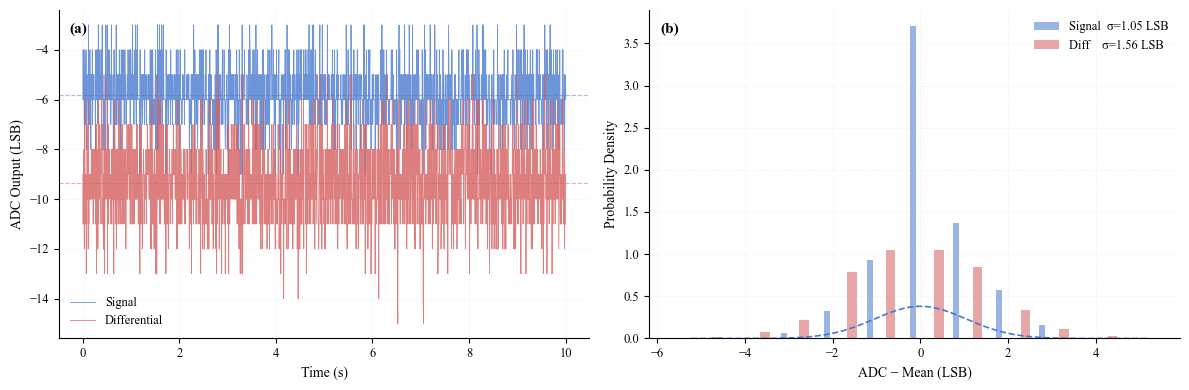

In [16]:
# Time-domain + distribution comparison (signal vs differential)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_show = min(2000, len(raw_clean))
t2 = np.arange(n_show) * DT

ax = axes[0]
ax.plot(t2, raw_clean[:n_show],  color=COLORS["blue"], linewidth=0.6, alpha=0.8, label="Signal")
ax.plot(t2, diff_clean[:n_show], color=COLORS["red"],  linewidth=0.6, alpha=0.8, label="Differential")
ax.axhline(signal_mean, color=COLORS["blue"], linewidth=0.8, linestyle="--", alpha=0.5)
ax.axhline(diff_mean,   color=COLORS["red"],  linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Time (s)"); ax.set_ylabel("ADC Output (LSB)")
ax.legend(frameon=False)
add_subplot_label(ax, "(a)")

ax = axes[1]
ax.hist(raw_clean  - signal_mean, bins=50, density=True, alpha=0.55,
        color=COLORS["blue"], edgecolor="none", label=f"Signal  σ={signal_std:.2f} LSB")
ax.hist(diff_clean - diff_mean,   bins=50, density=True, alpha=0.55,
        color=COLORS["red"],  edgecolor="none", label=f"Diff    σ={diff_std:.2f} LSB")
x_g2 = np.linspace(-5*signal_std, 5*signal_std, 200)
ax.plot(x_g2, norm.pdf(x_g2, 0, signal_std), color=COLORS["blue"], linewidth=1.2, linestyle="--")
ax.set_xlabel("ADC − Mean (LSB)"); ax.set_ylabel("Probability Density")
ax.legend(frameon=False)
add_subplot_label(ax, "(b)")

plt.tight_layout()
p = save_figure(fig, SAVE_DIR, "01_noise_analysis")
print(f"Saved: {p}")
plt.show()

#### 9. 有效位数（ENOB）计算

In [17]:
# 有效位数计算 (原始信号)
ENOB_signal = ADC_BITS - np.log2(signal_std * 6.6)
full_scale = 2**(ADC_BITS-1)
SNR_signal_dB = 20 * np.log10(full_scale / signal_std)

# 有效位数计算 (差分信号)
ENOB_diff = ADC_BITS - np.log2(diff_std * 6.6)
SNR_diff_dB = 20 * np.log10(full_scale / diff_std)

print("="*70)
print("【ADC性能指标】")
print("="*70)
print(f"{'指标':<20} {'原始信号':<20} {'差分信号':<20}")
print("-"*70)
print(f"{'噪声标准差(LSB)':<20} {signal_std:<20.3f} {diff_std:<20.3f}")
print(f"{'有效位数ENOB(bits)':<20} {ENOB_signal:<20.2f} {ENOB_diff:<20.2f}")
print(f"{'满量程SNR(dB)':<20} {SNR_signal_dB:<20.1f} {SNR_diff_dB:<20.1f}")
print()
print(f"差分带来的ENOB提升: {ENOB_diff - ENOB_signal:.2f} bits")

【ADC性能指标】
指标                   原始信号                 差分信号                
----------------------------------------------------------------------
噪声标准差(LSB)           1.045                1.562               
有效位数ENOB(bits)       13.21                12.63               
满量程SNR(dB)           89.9                 86.4                

差分带来的ENOB提升: -0.58 bits


#### 10. 结果汇总

In [18]:
# 保存噪声参数
noise_params = {
    # 原始信号
    'signal_mean_LSB': signal_mean,
    'signal_std_LSB': signal_std,
    'signal_pp_LSB': signal_pp,
    'signal_ENOB_bits': ENOB_signal,
    'signal_SNR_dB': SNR_signal_dB,
    # 参考地
    'ground_mean_LSB': ground_mean,
    'ground_std_LSB': ground_std,
    # 差分信号
    'diff_mean_LSB': diff_mean,
    'diff_std_LSB': diff_std,
    'diff_pp_LSB': diff_pp,
    'diff_ENOB_bits': ENOB_diff,
    'diff_SNR_dB': SNR_diff_dB,
    # 相关性
    'pearson_correlation': pearson_corr,
    'covariance_LSB2': covariance,
    # 降噪效果
    'noise_reduction_ratio': noise_reduction_ratio,
    'noise_reduction_percent': noise_reduction_percent,
    'noise_reduction_dB': noise_reduction_dB
}

pd.DataFrame([noise_params]).to_csv('01_noise_params.csv', index=False)

print("="*70)
print("【实验01 结果汇总】")
print("="*70)
print(f"""
┌──────────────────────────────────────────────────────────────────┐
│  噪声特性参数                                                    │
├──────────────────────────────────────────────────────────────────┤
│  原始信号噪声:                                                   │
│    标准差 σ:       {signal_std:>10.3f} LSB                             │
│    峰峰值:         {signal_pp:>10} LSB                             │
│    有效位数 ENOB:  {ENOB_signal:>10.2f} bits                            │
├──────────────────────────────────────────────────────────────────┤
│  参考地噪声:                                                     │
│    标准差 σ:       {ground_std:>10.3f} LSB                             │
├──────────────────────────────────────────────────────────────────┤
│  信号-参考地相关性:                                              │
│    Pearson相关系数: {pearson_corr:>10.4f}                               │
│    协方差:          {covariance:>10.4f} LSB²                            │
├──────────────────────────────────────────────────────────────────┤
│  差分信号噪声:                                                   │
│    标准差 σ:       {diff_std:>10.3f} LSB                             │
│    峰峰值:         {diff_pp:>10} LSB                             │
│    有效位数 ENOB:  {ENOB_diff:>10.2f} bits                            │
├──────────────────────────────────────────────────────────────────┤
│  差分降噪效果:                                                   │
│    噪声降低:       {noise_reduction_percent:>10.2f} %                              │
│    ENOB提升:       {ENOB_diff - ENOB_signal:>10.2f} bits                            │
└──────────────────────────────────────────────────────────────────┘
""")

if noise_reduction_percent > 10:
    print("★ 建议: 后续实验使用差分信号 (RawValue - RawGround) 可获得更好的信噪比")
else:
    print("★ 建议: 信号与参考地相关性较低，差分效果有限，建议直接使用原始信号")

print("\n噪声参数已保存至: 01_noise_params.csv")

【实验01 结果汇总】

┌──────────────────────────────────────────────────────────────────┐
│  噪声特性参数                                                    │
├──────────────────────────────────────────────────────────────────┤
│  原始信号噪声:                                                   │
│    标准差 σ:            1.045 LSB                             │
│    峰峰值:                  7 LSB                             │
│    有效位数 ENOB:       13.21 bits                            │
├──────────────────────────────────────────────────────────────────┤
│  参考地噪声:                                                     │
│    标准差 σ:            1.167 LSB                             │
├──────────────────────────────────────────────────────────────────┤
│  信号-参考地相关性:                                              │
│    Pearson相关系数:     0.0070                               │
│    协方差:              0.0086 LSB²                            │
├──────────────────────────────────────────────────────────────────┤
│  差分信号噪声:     